# Uniform HSBM n-scaling spectral clustering

This notebook generates uniform HSBM hypergraphs with `generate_planted_uniform_hsbm_instance`, runs spectral clustering with the Zhou normalized hypergraph Laplacian, and records misclassification rate, ARI, NMI, CPU time, wall-clock time, memory, and algorithm-step runtimes as `n` increases.

Uniform here means every sampled hyperedge has the same size `m`. Edit `CONFIG` or add another `df_n... = run_n_experiment(...)` cell to extend the sweep.


In [1]:
from pathlib import Path
import gc
import json
import sys
import time
import tracemalloc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "common.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find project root containing src/common.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common import (
    generate_planted_uniform_hsbm_instance,
    normalize_rows_l2,
    zhou_normalized_laplacian,
)

EXPERIMENT_ID = "EXP-20260426-004"
EXPERIMENT_SLUG = "uniform_hsbm_n_scaling_zhou_laplacian"
OUTDIR = PROJECT_ROOT / "experiments" / "\uade0\uc77c HSBM \uc2e4\ud5d8" / "results" / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}"
OUTDIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

EXPERIMENT_ID, EXPERIMENT_SLUG, PROJECT_ROOT, OUTDIR

('EXP-20260426-004',
 'uniform_hsbm_n_scaling_zhou_laplacian',
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian'))

## Configuration

`a_in`, `b_out`, and `rho_n` are mapped to `p_in = a_in * rho_n / n ** (m - 1)` and `p_out = b_out * rho_n / n ** (m - 1)`, matching the planted d-uniform HSBM model.


In [2]:
CONFIG = {
    "K": 3,
    "m": 3,
    "a_in": 36.0,
    "b_out": 4.0,
    "rho_n": 4.0,
    "reps": 10,
    "seed": 20260426,
    "sampling": "sparse",
    "max_enumeration": 1_500_000,
    "normalize_embedding_rows": True,
    "eigsh_tol": 1e-6,
}

N_VALUES = list(range(1000, 10001, 1000))

CONFIG, N_VALUES

({'K': 3,
  'm': 3,
  'a_in': 36.0,
  'b_out': 4.0,
  'rho_n': 4.0,
  'reps': 10,
  'seed': 20260426,
  'sampling': 'sparse',
  'max_enumeration': 1500000,
  'normalize_embedding_rows': True,
  'eigsh_tol': 1e-06},
 [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000])

## Helpers

In [3]:
def current_rss_mb():
    try:
        import psutil

        return psutil.Process().memory_info().rss / (1024.0 ** 2)
    except Exception:
        return np.nan


def measure_call(fn):
    gc.collect()
    rss_before_mb = current_rss_mb()
    tracemalloc.start()
    cpu_start = time.process_time()
    wall_start = time.perf_counter()
    value = fn()
    wall_clock_sec = time.perf_counter() - wall_start
    cpu_time_sec = time.process_time() - cpu_start
    current_bytes, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rss_after_mb = current_rss_mb()
    return value, {
        "cpu_time_sec": float(cpu_time_sec),
        "wall_clock_sec": float(wall_clock_sec),
        "peak_traced_memory_mb": float(peak_bytes / (1024.0 ** 2)),
        "rss_before_mb": float(rss_before_mb) if np.isfinite(rss_before_mb) else np.nan,
        "rss_after_mb": float(rss_after_mb) if np.isfinite(rss_after_mb) else np.nan,
        "rss_delta_mb": float(rss_after_mb - rss_before_mb)
        if np.isfinite(rss_before_mb) and np.isfinite(rss_after_mb)
        else np.nan,
    }


def aligned_misclassification_rate(y_true, y_pred, K):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    conf = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if 0 <= t < K and 0 <= p < K:
            conf[t, p] += 1
    true_ids, pred_ids = linear_sum_assignment(-conf)
    pred_to_true = {int(pred): int(true) for true, pred in zip(true_ids, pred_ids)}
    y_aligned = np.array([pred_to_true.get(int(p), int(p)) for p in y_pred], dtype=int)
    return float(np.mean(y_aligned != y_true)), y_aligned, conf


def hypergraph_vertex_degree_stats(n, hyperedges):
    degrees = np.zeros(int(n), dtype=float)
    for edge in hyperedges:
        for v in edge:
            degrees[int(v)] += 1.0
    return {
        "num_isolated_nodes": int(np.sum(degrees == 0)),
        "hypergraph_degree_mean": float(degrees.mean()) if n > 0 else 0.0,
        "hypergraph_degree_max": float(degrees.max()) if n > 0 else 0.0,
    }


def spectral_cluster_from_zhou_theta(theta, K, rng, normalize_rows=True, eigsh_tol=1e-6):
    n = int(theta.shape[0])
    theta = ((theta + theta.T) * 0.5).tocsr()
    total_start = time.perf_counter()
    timings = {}

    t0 = time.perf_counter()
    if n <= K + 1:
        vals, vecs = np.linalg.eigh(theta.toarray())
        order = np.argsort(vals)[-K:][::-1]
        U = vecs[:, order]
    else:
        try:
            v0 = rng.normal(size=n)
            vals, vecs = spla.eigsh(theta, k=K, which="LA", tol=eigsh_tol, v0=v0)
            order = np.argsort(vals)[::-1]
            U = vecs[:, order]
        except Exception as exc:
            warnings.warn(f"eigsh failed ({exc}); falling back to dense eigh.")
            vals, vecs = np.linalg.eigh(theta.toarray())
            order = np.argsort(vals)[-K:][::-1]
            U = vecs[:, order]
    timings["eigen_decomposition_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    if normalize_rows:
        U = normalize_rows_l2(U)
    timings["embedding_normalize_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_state = int(rng.integers(1, 2**31 - 1))
    labels = KMeans(n_clusters=K, n_init=20, random_state=random_state).fit_predict(U)
    timings["kmeans_wall_sec"] = time.perf_counter() - t0
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - total_start
    return labels, {
        "zhou_theta_nnz": int(theta.nnz),
        **timings,
    }


def run_one_rep(n, rep, config):
    K = int(config["K"])
    m = int(config["m"])
    seed = int(config["seed"] + 1_000_003 * int(n) + int(rep))
    rng = np.random.default_rng(seed)
    timings = {}
    t0 = time.perf_counter()
    hyperedges, y_true, Theta_true, gen_stats = generate_planted_uniform_hsbm_instance(
        n=n,
        K=K,
        d=m,
        a_d=float(config["a_in"]),
        b_d=float(config["b_out"]),
        rho_n=float(config["rho_n"]),
        rng=rng,
        sampling=config["sampling"],
        max_enumeration=int(config["max_enumeration"]),
        clip=False,
    )
    p_in = float(gen_stats["p_in"])
    p_out = float(gen_stats["p_out"])
    timings["generation_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    L = zhou_normalized_laplacian(n=n, hyperedges=hyperedges)
    theta = (sp.eye(n, format="csr", dtype=float) - L).tocsr()
    theta.eliminate_zeros()
    timings["zhou_laplacian_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred, spectral_stats = spectral_cluster_from_zhou_theta(
        theta=theta,
        K=K,
        rng=rng,
        normalize_rows=bool(config["normalize_embedding_rows"]),
        eigsh_tol=float(config["eigsh_tol"]),
    )
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    mis, y_aligned, conf = aligned_misclassification_rate(y_true, y_pred, K)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    timings["metric_wall_sec"] = time.perf_counter() - t0

    record = {
        "n": int(n),
        "rep": int(rep),
        "seed": seed,
        "K": K,
        "m": m,
        "num_hyperedges_total": int(len(hyperedges)),
        "misclassification_rate": mis,
        "ARI": float(ari),
        "NMI": float(nmi),
        **timings,
        **hypergraph_vertex_degree_stats(n, hyperedges),
        **spectral_stats,
    }
    record["algorithm_total_wall_sec"] = float(
        record["generation_wall_sec"]
        + record["zhou_laplacian_wall_sec"]
        + record["eigen_decomposition_wall_sec"]
        + record["embedding_normalize_wall_sec"]
        + record["kmeans_wall_sec"]
    )
    record["rho_n"] = float(config["rho_n"])
    record["p_in"] = float(p_in)
    record["p_out"] = float(p_out)
    record["sampling_mode"] = gen_stats.get("sampling_mode", "")
    return record


def run_one_rep_measured(n, rep, config):
    record, measurement = measure_call(lambda: run_one_rep(n, rep, config))
    record.update(measurement)
    return record


def run_n_experiment(n, reps=None, config=None):
    if config is None:
        config = CONFIG
    if reps is None:
        reps = int(config["reps"])

    rows = []
    for rep in range(1, reps + 1):
        row = run_one_rep_measured(n=n, rep=rep, config=config)
        rows.append(row)
        print(
            f"n={n:5d} rep={rep:2d}/{reps:<2d} "
            f"edges={row['num_hyperedges_total']:6d} "
            f"mis={row['misclassification_rate']:.4f} "
            f"ARI={row['ARI']:.4f} NMI={row['NMI']:.4f} "
            f"eig={row['eigen_decomposition_wall_sec']:.3f}s "
            f"km={row['kmeans_wall_sec']:.3f}s "
            f"wall={row['wall_clock_sec']:.3f}s "
            f"peak={row['peak_traced_memory_mb']:.1f}MB"
        )

    df = pd.DataFrame(rows)
    display(df)
    return df


def summarize_by_n(df_raw):
    return df_raw.groupby("n", as_index=False).agg(
        reps=("rep", "count"),
        hyperedges_mean=("num_hyperedges_total", "mean"),
        hyperedges_std=("num_hyperedges_total", "std"),
        misclassification_mean=("misclassification_rate", "mean"),
        misclassification_std=("misclassification_rate", "std"),
        ari_mean=("ARI", "mean"),
        ari_std=("ARI", "std"),
        nmi_mean=("NMI", "mean"),
        nmi_std=("NMI", "std"),
        generation_wall_sec_mean=("generation_wall_sec", "mean"),
        generation_wall_sec_std=("generation_wall_sec", "std"),
        zhou_laplacian_wall_sec_mean=("zhou_laplacian_wall_sec", "mean"),
        zhou_laplacian_wall_sec_std=("zhou_laplacian_wall_sec", "std"),
        eigen_decomposition_wall_sec_mean=("eigen_decomposition_wall_sec", "mean"),
        eigen_decomposition_wall_sec_std=("eigen_decomposition_wall_sec", "std"),
        embedding_normalize_wall_sec_mean=("embedding_normalize_wall_sec", "mean"),
        embedding_normalize_wall_sec_std=("embedding_normalize_wall_sec", "std"),
        kmeans_wall_sec_mean=("kmeans_wall_sec", "mean"),
        kmeans_wall_sec_std=("kmeans_wall_sec", "std"),
        spectral_clustering_wall_sec_mean=("spectral_clustering_wall_sec", "mean"),
        spectral_clustering_wall_sec_std=("spectral_clustering_wall_sec", "std"),
        metric_wall_sec_mean=("metric_wall_sec", "mean"),
        metric_wall_sec_std=("metric_wall_sec", "std"),
        algorithm_total_wall_sec_mean=("algorithm_total_wall_sec", "mean"),
        algorithm_total_wall_sec_std=("algorithm_total_wall_sec", "std"),
        cpu_time_sec_mean=("cpu_time_sec", "mean"),
        cpu_time_sec_std=("cpu_time_sec", "std"),
        wall_clock_sec_mean=("wall_clock_sec", "mean"),
        wall_clock_sec_std=("wall_clock_sec", "std"),
        peak_traced_memory_mb_mean=("peak_traced_memory_mb", "mean"),
        peak_traced_memory_mb_std=("peak_traced_memory_mb", "std"),
        rss_delta_mb_mean=("rss_delta_mb", "mean"),
        rss_delta_mb_std=("rss_delta_mb", "std"),
    )

## n = 1000

In [4]:
df_n1000 = run_n_experiment(1000)

n= 1000 rep= 1/10 edges=  5028 mis=0.0230 ARI=0.9319 NMI=0.8926 eig=0.002s km=0.164s wall=0.354s peak=2.5MB
n= 1000 rep= 2/10 edges=  4841 mis=0.0160 ARI=0.9526 NMI=0.9200 eig=0.002s km=0.045s wall=0.261s peak=2.4MB
n= 1000 rep= 3/10 edges=  5101 mis=0.0200 ARI=0.9408 NMI=0.9012 eig=0.002s km=0.040s wall=0.259s peak=2.5MB
n= 1000 rep= 4/10 edges=  4913 mis=0.0170 ARI=0.9495 NMI=0.9126 eig=0.002s km=0.039s wall=0.261s peak=2.5MB
n= 1000 rep= 5/10 edges=  4986 mis=0.0130 ARI=0.9613 NMI=0.9293 eig=0.002s km=0.040s wall=0.252s peak=2.5MB
n= 1000 rep= 6/10 edges=  5085 mis=0.0170 ARI=0.9495 NMI=0.9156 eig=0.002s km=0.040s wall=0.262s peak=2.5MB
n= 1000 rep= 7/10 edges=  5164 mis=0.0140 ARI=0.9584 NMI=0.9252 eig=0.002s km=0.035s wall=0.278s peak=2.6MB
n= 1000 rep= 8/10 edges=  5102 mis=0.0180 ARI=0.9467 NMI=0.9083 eig=0.002s km=0.039s wall=0.270s peak=2.5MB
n= 1000 rep= 9/10 edges=  5131 mis=0.0120 ARI=0.9643 NMI=0.9350 eig=0.002s km=0.037s wall=0.263s peak=2.6MB
n= 1000 rep=10/10 edges=  49

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,1000,1,1020263427,3,3,5028,0.023,0.931926,0.892609,0.152391,0.012090,0.165943,0.008786,0,15.084,26.0,30538,0.001891,0.000035,0.164006,0.330414,4.0,0.000144,0.000016,sparse,1.171635,0.354049,2.533737,263.437500,267.890625,4.453125
1,1000,2,1020263428,3,3,4841,0.016,0.952566,0.920037,0.182811,0.011970,0.047312,0.004869,0,14.523,28.0,29398,0.001820,0.000035,0.045454,0.242090,4.0,0.000144,0.000016,sparse,1.713189,0.261251,2.425808,267.890625,269.359375,1.468750
2,1000,3,1020263429,3,3,5101,0.020,0.940775,0.901199,0.178019,0.012008,0.042236,0.006709,0,15.303,29.0,30874,0.001857,0.000033,0.040343,0.232261,4.0,0.000144,0.000016,sparse,2.153518,0.258728,2.546162,269.359375,271.593750,2.234375
3,1000,4,1020263430,3,3,4913,0.017,0.949532,0.912641,0.181989,0.011955,0.041000,0.010139,0,14.739,27.0,29776,0.001841,0.000031,0.039123,0.234940,4.0,0.000144,0.000016,sparse,2.029250,0.260640,2.457971,271.593750,272.140625,0.546875
4,1000,5,1020263431,3,3,4986,0.013,0.961309,0.929286,0.179651,0.012138,0.041459,0.004841,0,14.958,28.0,30304,0.001920,0.000033,0.039502,0.233245,4.0,0.000144,0.000016,sparse,1.999874,0.251954,2.496489,272.140625,273.093750,0.953125
5,1000,6,1020263432,3,3,5085,0.017,0.949524,0.915557,0.187710,0.012104,0.042273,0.004827,0,15.255,30.0,30830,0.002210,0.000036,0.040025,0.242085,4.0,0.000144,0.000016,sparse,2.073858,0.261776,2.543060,273.093750,273.687500,0.593750
6,1000,7,1020263433,3,3,5164,0.014,0.958400,0.925156,0.204214,0.012532,0.036483,0.009348,0,15.492,30.0,31320,0.001861,0.000032,0.034588,0.253226,4.0,0.000144,0.000016,sparse,2.056394,0.277797,2.580728,273.687500,274.031250,0.343750
7,1000,8,1020263434,3,3,5102,0.018,0.946668,0.908279,0.192268,0.012816,0.040836,0.004818,0,15.306,31.0,30918,0.001819,0.000034,0.038982,0.245918,4.0,0.000144,0.000016,sparse,2.087665,0.270285,2.549037,274.031250,274.546875,0.515625
8,1000,9,1020263435,3,3,5131,0.012,0.964298,0.935002,0.188007,0.012264,0.038953,0.007554,0,15.393,27.0,31130,0.002256,0.000036,0.036659,0.239222,4.0,0.000144,0.000016,sparse,2.014861,0.262744,2.563955,274.546875,275.015625,0.468750
9,1000,10,1020263436,3,3,4934,0.016,0.952484,0.916252,0.178853,0.011948,0.039445,0.004747,0,14.802,28.0,29986,0.001862,0.000032,0.037549,0.230244,4.0,0.000144,0.000016,sparse,2.059304,0.250990,2.468428,275.015625,275.296875,0.281250


## n = 2000

In [5]:
df_n2000 = run_n_experiment(2000)

n= 2000 rep= 1/10 edges= 10073 mis=0.0180 ARI=0.9467 NMI=0.9072 eig=0.003s km=0.047s wall=0.475s peak=5.2MB
n= 2000 rep= 2/10 edges= 10034 mis=0.0185 ARI=0.9453 NMI=0.9057 eig=0.003s km=0.051s wall=0.479s peak=5.2MB
n= 2000 rep= 3/10 edges= 10121 mis=0.0195 ARI=0.9424 NMI=0.9020 eig=0.003s km=0.055s wall=0.499s peak=5.2MB
n= 2000 rep= 4/10 edges= 10056 mis=0.0170 ARI=0.9496 NMI=0.9123 eig=0.003s km=0.065s wall=0.498s peak=5.2MB
n= 2000 rep= 5/10 edges= 10120 mis=0.0195 ARI=0.9423 NMI=0.9007 eig=0.003s km=0.069s wall=0.489s peak=5.2MB
n= 2000 rep= 6/10 edges= 10014 mis=0.0135 ARI=0.9599 NMI=0.9280 eig=0.003s km=0.066s wall=0.484s peak=5.2MB
n= 2000 rep= 7/10 edges=  9950 mis=0.0190 ARI=0.9438 NMI=0.9036 eig=0.003s km=0.067s wall=0.486s peak=5.1MB
n= 2000 rep= 8/10 edges= 10077 mis=0.0195 ARI=0.9424 NMI=0.9032 eig=0.003s km=0.068s wall=0.491s peak=5.2MB
n= 2000 rep= 9/10 edges= 10043 mis=0.0175 ARI=0.9482 NMI=0.9107 eig=0.003s km=0.067s wall=0.498s peak=5.2MB
n= 2000 rep=10/10 edges= 101

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,2000,1,2020266427,3,3,10073,0.0180,0.946672,0.907246,0.364641,0.022133,0.050314,0.008648,0,15.1095,29.0,61814,0.002801,0.000037,0.047473,0.437085,4.0,0.000036,0.000004,sparse,2.388321,0.475361,5.183400,275.671875,278.937500,3.265625
1,2000,2,2020266428,3,3,10034,0.0185,0.945267,0.905656,0.362484,0.021785,0.053185,0.007827,0,15.0510,30.0,61550,0.002620,0.000049,0.050513,0.437451,4.0,0.000036,0.000004,sparse,2.389501,0.478751,5.162624,278.937500,280.437500,1.500000
2,2000,3,2020266429,3,3,10121,0.0195,0.942353,0.901984,0.372136,0.022010,0.058173,0.008354,0,15.1815,29.0,62020,0.002887,0.000045,0.055238,0.452316,4.0,0.000036,0.000004,sparse,2.378441,0.498564,5.199759,280.437500,281.578125,1.140625
3,2000,4,2020266430,3,3,10056,0.0170,0.949644,0.912324,0.350073,0.023909,0.068097,0.013872,0,15.0840,32.0,61714,0.002697,0.000093,0.065301,0.442073,4.0,0.000036,0.000004,sparse,2.381352,0.497768,5.176728,281.578125,283.843750,2.265625
4,2000,5,2020266431,3,3,10120,0.0195,0.942315,0.900739,0.354989,0.022043,0.071820,0.008033,0,15.1800,29.0,62082,0.002768,0.000037,0.069013,0.448849,4.0,0.000036,0.000004,sparse,2.202455,0.489051,5.205267,283.843750,283.968750,0.125000
5,2000,6,2020266432,3,3,10014,0.0135,0.959910,0.928045,0.344874,0.021937,0.069263,0.010271,0,15.0210,29.0,61458,0.002829,0.000038,0.066394,0.436072,4.0,0.000036,0.000004,sparse,2.504703,0.484165,5.158007,283.968750,284.109375,0.140625
6,2000,7,2020266433,3,3,9950,0.0190,0.943783,0.903638,0.352641,0.024172,0.069376,0.008484,0,14.9250,28.0,61038,0.002743,0.000048,0.066582,0.446186,4.0,0.000036,0.000004,sparse,2.311396,0.485881,5.123786,284.109375,284.921875,0.812500
7,2000,8,2020266434,3,3,10077,0.0195,0.942352,0.903165,0.354801,0.022525,0.071017,0.009793,0,15.1155,29.0,61842,0.002775,0.000043,0.068194,0.448339,4.0,0.000036,0.000004,sparse,2.400008,0.491129,5.185515,284.921875,285.875000,0.953125
8,2000,9,2020266435,3,3,10043,0.0175,0.948180,0.910675,0.364625,0.022135,0.070364,0.010075,0,15.0645,30.0,61664,0.003132,0.000112,0.067117,0.457121,4.0,0.000036,0.000004,sparse,2.348582,0.497649,5.172143,285.875000,286.187500,0.312500
9,2000,10,2020266436,3,3,10180,0.0145,0.956967,0.923569,0.357325,0.022691,0.062867,0.010169,0,15.2700,29.0,62414,0.002821,0.000041,0.060003,0.442881,4.0,0.000036,0.000004,sparse,2.414343,0.492944,5.234224,286.187500,286.484375,0.296875


## n = 3000

In [6]:
df_n3000 = run_n_experiment(3000)

n= 3000 rep= 1/10 edges= 15110 mis=0.0177 ARI=0.9477 NMI=0.9081 eig=0.004s km=0.067s wall=0.684s peak=7.8MB
n= 3000 rep= 2/10 edges= 15089 mis=0.0123 ARI=0.9633 NMI=0.9320 eig=0.004s km=0.062s wall=0.714s peak=7.8MB
n= 3000 rep= 3/10 edges= 15205 mis=0.0137 ARI=0.9594 NMI=0.9265 eig=0.004s km=0.064s wall=0.718s peak=7.9MB
n= 3000 rep= 4/10 edges= 15357 mis=0.0127 ARI=0.9623 NMI=0.9308 eig=0.004s km=0.073s wall=0.689s peak=8.0MB
n= 3000 rep= 5/10 edges= 15167 mis=0.0220 ARI=0.9351 NMI=0.8911 eig=0.004s km=0.057s wall=0.671s peak=7.9MB
n= 3000 rep= 6/10 edges= 15114 mis=0.0160 ARI=0.9526 NMI=0.9157 eig=0.005s km=0.077s wall=0.763s peak=7.8MB
n= 3000 rep= 7/10 edges= 15008 mis=0.0170 ARI=0.9496 NMI=0.9111 eig=0.004s km=0.075s wall=0.798s peak=7.8MB
n= 3000 rep= 8/10 edges= 15233 mis=0.0133 ARI=0.9604 NMI=0.9283 eig=0.004s km=0.066s wall=0.744s peak=7.9MB
n= 3000 rep= 9/10 edges= 15169 mis=0.0120 ARI=0.9643 NMI=0.9337 eig=0.004s km=0.061s wall=0.682s peak=7.9MB
n= 3000 rep=10/10 edges= 151

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,3000,1,3020269427,3,3,15110,0.017667,0.947670,0.908094,0.520261,0.033458,0.070780,0.011352,0,15.110,29.0,93020,0.003731,0.000059,0.066987,0.624495,4.0,0.000016,0.000002,sparse,2.506531,0.684259,7.844920,286.484375,290.234375,3.750000
1,3000,2,3020269428,3,3,15089,0.012333,0.963321,0.932013,0.536253,0.051601,0.065797,0.013024,0,15.089,30.0,92890,0.003810,0.000051,0.061931,0.653646,4.0,0.000016,0.000002,sparse,2.503358,0.713793,7.832294,290.234375,291.375000,1.140625
2,3000,3,3020269429,3,3,15205,0.013667,0.959411,0.926522,0.541896,0.032556,0.067891,0.015321,0,15.205,31.0,93556,0.003697,0.000049,0.064140,0.642337,4.0,0.000016,0.000002,sparse,2.524961,0.718374,7.891184,291.375000,292.968750,1.593750
3,3000,4,3020269430,3,3,15357,0.012667,0.962344,0.930781,0.516217,0.032506,0.077025,0.010521,0,15.357,31.0,94456,0.003717,0.000046,0.073259,0.625745,4.0,0.000016,0.000002,sparse,2.349195,0.689159,7.967147,292.968750,293.687500,0.718750
4,3000,5,3020269431,3,3,15167,0.022000,0.935081,0.891050,0.517411,0.032897,0.061124,0.012279,0,15.167,31.0,93316,0.003745,0.000043,0.057333,0.611428,4.0,0.000016,0.000002,sparse,2.516495,0.671237,7.869307,293.687500,295.828125,2.140625
5,3000,6,3020269432,3,3,15114,0.016000,0.952552,0.915744,0.560896,0.037661,0.081956,0.015015,0,15.114,31.0,93034,0.004652,0.000172,0.077125,0.680506,4.0,0.000016,0.000002,sparse,2.747210,0.763226,7.845171,295.828125,297.500000,1.671875
6,3000,7,3020269433,3,3,15008,0.017000,0.949626,0.911098,0.596007,0.047840,0.079751,0.014466,0,15.008,31.0,92370,0.004405,0.000069,0.075273,0.723594,4.0,0.000016,0.000002,sparse,2.356744,0.798034,7.791274,297.500000,302.296875,4.796875
7,3000,8,3020269434,3,3,15233,0.013333,0.960396,0.928338,0.564277,0.034273,0.070479,0.015215,0,15.233,30.0,93792,0.004004,0.000053,0.066418,0.669025,4.0,0.000016,0.000002,sparse,2.260754,0.743989,7.909341,302.296875,302.343750,0.046875
8,3000,9,3020269435,3,3,15169,0.012000,0.964310,0.933712,0.525884,0.033427,0.064563,0.014147,0,15.169,31.0,93346,0.003926,0.000054,0.060579,0.623870,4.0,0.000016,0.000002,sparse,2.314110,0.681849,7.872066,302.343750,304.109375,1.765625
9,3000,10,3020269436,3,3,15125,0.016667,0.950635,0.913920,0.571131,0.032967,0.083127,0.014801,0,15.125,34.0,93102,0.003737,0.000043,0.079343,0.687220,4.0,0.000016,0.000002,sparse,2.781047,0.760166,7.855258,304.109375,304.578125,0.468750


## n = 4000

In [7]:
df_n4000 = run_n_experiment(4000)

n= 4000 rep= 1/10 edges= 20134 mis=0.0230 ARI=0.9322 NMI=0.8873 eig=0.005s km=0.067s wall=0.898s peak=10.5MB
n= 4000 rep= 2/10 edges= 20403 mis=0.0192 ARI=0.9431 NMI=0.9019 eig=0.005s km=0.065s wall=0.942s peak=10.6MB
n= 4000 rep= 3/10 edges= 20027 mis=0.0140 ARI=0.9584 NMI=0.9247 eig=0.005s km=0.081s wall=0.905s peak=10.4MB
n= 4000 rep= 4/10 edges= 20146 mis=0.0165 ARI=0.9511 NMI=0.9133 eig=0.005s km=0.065s wall=0.876s peak=10.5MB
n= 4000 rep= 5/10 edges= 20006 mis=0.0143 ARI=0.9577 NMI=0.9243 eig=0.005s km=0.081s wall=0.972s peak=10.4MB
n= 4000 rep= 6/10 edges= 20189 mis=0.0222 ARI=0.9343 NMI=0.8898 eig=0.005s km=0.097s wall=0.955s peak=10.5MB
n= 4000 rep= 7/10 edges= 20091 mis=0.0182 ARI=0.9460 NMI=0.9056 eig=0.005s km=0.123s wall=0.979s peak=10.5MB
n= 4000 rep= 8/10 edges= 20286 mis=0.0163 ARI=0.9518 NMI=0.9146 eig=0.011s km=0.075s wall=0.965s peak=10.6MB
n= 4000 rep= 9/10 edges= 20053 mis=0.0190 ARI=0.9438 NMI=0.9038 eig=0.005s km=0.088s wall=0.919s peak=10.5MB
n= 4000 rep=10/10 e

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,4000,1,4020272427,3,3,20134,0.02300,0.932215,0.887314,0.692353,0.044532,0.072127,0.016873,0,15.10050,31.0,124190,0.004817,0.000057,0.067250,0.809008,4.0,0.000009,0.000001,sparse,2.482931,0.898060,10.502934,304.578125,307.140625,2.562500
1,4000,2,4020272428,3,3,20403,0.01925,0.943055,0.901932,0.716640,0.042478,0.070216,0.018683,0,15.30225,30.0,125716,0.004729,0.000051,0.065433,0.829330,4.0,0.000009,0.000001,sparse,2.891616,0.942374,10.630378,307.140625,309.234375,2.093750
2,4000,3,4020272429,3,3,20027,0.01400,0.958435,0.924731,0.705120,0.041881,0.085621,0.013361,0,15.02025,31.0,123464,0.004651,0.000063,0.080904,0.832619,4.0,0.000009,0.000001,sparse,2.439247,0.905298,10.446263,309.234375,310.406250,1.171875
3,4000,4,4020272430,3,3,20146,0.01650,0.951089,0.913307,0.671638,0.040789,0.069747,0.014732,0,15.10950,32.0,124230,0.004629,0.000046,0.065069,0.782171,4.0,0.000009,0.000001,sparse,2.857149,0.875623,10.510488,310.406250,311.953125,1.546875
4,4000,5,4020272431,3,3,20006,0.01425,0.957695,0.924259,0.744785,0.041342,0.085735,0.017105,0,15.00450,29.0,123342,0.004701,0.000056,0.080975,0.871858,4.0,0.000009,0.000001,sparse,2.791893,0.972348,10.437577,311.953125,314.546875,2.593750
5,4000,6,4020272432,3,3,20189,0.02225,0.934334,0.889765,0.708912,0.042038,0.101824,0.018094,0,15.14175,31.0,124464,0.004727,0.000060,0.097033,0.852771,4.0,0.000009,0.000001,sparse,2.850352,0.955096,10.525846,314.546875,315.062500,0.515625
6,4000,7,4020272433,3,3,20091,0.01825,0.945972,0.905585,0.717463,0.041770,0.127359,0.018748,0,15.06825,35.0,123956,0.004633,0.000053,0.122669,0.886588,4.0,0.000009,0.000001,sparse,3.164513,0.978714,10.483419,315.062500,317.218750,2.156250
7,4000,8,4020272434,3,3,20286,0.01625,0.951827,0.914604,0.712032,0.058794,0.086178,0.018605,0,15.21450,30.0,125104,0.011371,0.000080,0.074720,0.856997,4.0,0.000009,0.000001,sparse,2.724248,0.965470,10.578161,317.218750,319.625000,2.406250
8,4000,9,4020272435,3,3,20053,0.01900,0.943785,0.903755,0.673891,0.041729,0.092769,0.019567,0,15.03975,30.0,123678,0.004845,0.000051,0.087870,0.808386,4.0,0.000009,0.000001,sparse,2.663292,0.918692,10.462222,319.625000,320.046875,0.421875
9,4000,10,4020272436,3,3,20146,0.01725,0.948894,0.910635,0.683838,0.041444,0.071106,0.018680,0,15.10950,31.0,124172,0.004679,0.000049,0.066372,0.796382,4.0,0.000009,0.000001,sparse,2.376344,0.894522,10.504559,320.046875,320.656250,0.609375


## n = 5000

In [8]:
df_n5000 = run_n_experiment(5000)

n= 5000 rep= 1/10 edges= 25130 mis=0.0180 ARI=0.9467 NMI=0.9068 eig=0.006s km=0.076s wall=1.105s peak=13.1MB
n= 5000 rep= 2/10 edges= 25223 mis=0.0178 ARI=0.9473 NMI=0.9078 eig=0.006s km=0.088s wall=1.100s peak=13.2MB
n= 5000 rep= 3/10 edges= 25161 mis=0.0168 ARI=0.9502 NMI=0.9129 eig=0.006s km=0.066s wall=1.126s peak=13.2MB
n= 5000 rep= 4/10 edges= 25115 mis=0.0184 ARI=0.9456 NMI=0.9054 eig=0.006s km=0.072s wall=1.180s peak=13.1MB
n= 5000 rep= 5/10 edges= 25001 mis=0.0186 ARI=0.9450 NMI=0.9048 eig=0.006s km=0.132s wall=1.204s peak=13.1MB
n= 5000 rep= 6/10 edges= 25231 mis=0.0166 ARI=0.9508 NMI=0.9127 eig=0.006s km=0.131s wall=1.183s peak=13.2MB
n= 5000 rep= 7/10 edges= 25025 mis=0.0140 ARI=0.9584 NMI=0.9245 eig=0.006s km=0.068s wall=1.136s peak=13.1MB
n= 5000 rep= 8/10 edges= 24981 mis=0.0170 ARI=0.9496 NMI=0.9111 eig=0.006s km=0.066s wall=1.125s peak=13.1MB
n= 5000 rep= 9/10 edges= 25116 mis=0.0154 ARI=0.9543 NMI=0.9185 eig=0.006s km=0.069s wall=1.183s peak=13.1MB
n= 5000 rep=10/10 e

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,5000,1,5020275427,3,3,25130,0.0180,0.946716,0.906828,0.812275,0.080894,0.082015,0.021091,0,15.0780,32.0,155120,0.006017,0.000073,0.075922,0.975180,4.0,0.000006,6.400000e-07,sparse,2.980512,1.104528,13.140908,320.656250,323.468750,2.812500
1,5000,2,5020275428,3,3,25223,0.0178,0.947304,0.907816,0.846809,0.052051,0.093568,0.017963,0,15.1338,32.0,155644,0.005682,0.000059,0.087825,0.992424,4.0,0.000006,6.400000e-07,sparse,2.946897,1.099781,13.182880,323.468750,324.828125,1.359375
2,5000,3,5020275429,3,3,25161,0.0168,0.950239,0.912852,0.892816,0.053306,0.071918,0.017042,0,15.0966,30.0,155348,0.005752,0.000161,0.066003,1.018038,4.0,0.000006,6.400000e-07,sparse,3.062821,1.126292,13.161386,324.828125,325.812500,0.984375
3,5000,4,5020275430,3,3,25115,0.0184,0.945553,0.905433,0.941972,0.053863,0.078179,0.019177,0,15.0690,31.0,155064,0.005629,0.000052,0.072494,1.074012,4.0,0.000006,6.400000e-07,sparse,3.169742,1.180063,13.134447,325.812500,327.031250,1.218750
4,5000,5,5020275431,3,3,25001,0.0186,0.944974,0.904809,0.908553,0.053677,0.137445,0.020243,0,15.0006,36.0,154296,0.005622,0.000055,0.131766,1.099672,4.0,0.000006,6.400000e-07,sparse,3.662185,1.203879,13.073778,327.031250,327.531250,0.500000
5,5000,6,5020275432,3,3,25231,0.0166,0.950803,0.912744,0.890774,0.052706,0.136963,0.017961,0,15.1386,33.0,155666,0.005666,0.000057,0.131236,1.080440,4.0,0.000006,6.400000e-07,sparse,3.572692,1.182515,13.190331,327.531250,327.546875,0.015625
6,5000,7,5020275433,3,3,25025,0.0140,0.958425,0.924495,0.899319,0.053957,0.074109,0.019679,0,15.0150,30.0,154490,0.005656,0.000057,0.068391,1.027380,4.0,0.000006,6.400000e-07,sparse,3.009160,1.135622,13.086065,327.546875,327.609375,0.062500
7,5000,8,5020275434,3,3,24981,0.0170,0.949634,0.911150,0.879997,0.051832,0.071424,0.020341,0,14.9886,30.0,154244,0.005853,0.000061,0.065508,1.003250,4.0,0.000006,6.400000e-07,sparse,3.025404,1.124760,13.064729,327.609375,327.703125,0.093750
8,5000,9,5020275435,3,3,25116,0.0154,0.954331,0.918503,0.924377,0.052332,0.074852,0.023637,0,15.0696,30.0,155024,0.005735,0.000063,0.069050,1.051558,4.0,0.000006,6.400000e-07,sparse,3.122088,1.183018,13.134630,327.703125,327.812500,0.109375
9,5000,10,5020275436,3,3,24918,0.0238,0.929840,0.883030,0.829621,0.052161,0.073832,0.019558,0,14.9508,31.0,153934,0.005675,0.000060,0.068093,0.955611,4.0,0.000006,6.400000e-07,sparse,2.701975,1.060601,13.039480,327.812500,329.171875,1.359375


## n = 6000

In [9]:
df_n6000 = run_n_experiment(6000)

n= 6000 rep= 1/10 edges= 30241 mis=0.0202 ARI=0.9404 NMI=0.8980 eig=0.007s km=0.083s wall=1.231s peak=15.8MB
n= 6000 rep= 2/10 edges= 30319 mis=0.0158 ARI=0.9531 NMI=0.9165 eig=0.007s km=0.106s wall=1.433s peak=15.9MB
n= 6000 rep= 3/10 edges= 30017 mis=0.0185 ARI=0.9453 NMI=0.9052 eig=0.007s km=0.066s wall=1.357s peak=15.7MB
n= 6000 rep= 4/10 edges= 29958 mis=0.0168 ARI=0.9502 NMI=0.9123 eig=0.007s km=0.064s wall=1.351s peak=15.7MB
n= 6000 rep= 5/10 edges= 30371 mis=0.0118 ARI=0.9648 NMI=0.9344 eig=0.007s km=0.083s wall=1.388s peak=15.9MB
n= 6000 rep= 6/10 edges= 30316 mis=0.0167 ARI=0.9506 NMI=0.9137 eig=0.007s km=0.142s wall=1.428s peak=15.9MB
n= 6000 rep= 7/10 edges= 30192 mis=0.0165 ARI=0.9511 NMI=0.9133 eig=0.007s km=0.073s wall=1.351s peak=15.8MB
n= 6000 rep= 8/10 edges= 30209 mis=0.0180 ARI=0.9467 NMI=0.9066 eig=0.007s km=0.088s wall=1.404s peak=15.8MB
n= 6000 rep= 9/10 edges= 30612 mis=0.0163 ARI=0.9516 NMI=0.9142 eig=0.007s km=0.078s wall=1.390s peak=16.0MB
n= 6000 rep=10/10 e

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,6000,1,6020278427,3,3,30241,0.020167,0.940420,0.897978,0.948193,0.064217,0.090019,0.023218,0,15.1205,30.0,186800,0.007139,0.000078,0.082799,1.102426,4.0,0.000004,4.444444e-07,sparse,2.993026,1.231498,15.839649,329.171875,331.687500,2.515625
1,6000,2,6020278428,3,3,30319,0.015833,0.953063,0.916541,1.116257,0.066500,0.112882,0.021818,0,15.1595,30.0,187254,0.006569,0.000061,0.106249,1.295636,4.0,0.000004,4.444444e-07,sparse,3.699112,1.432975,15.882506,331.687500,336.343750,4.656250
2,6000,3,6020278429,3,3,30017,0.018500,0.945251,0.905188,1.087250,0.063907,0.072650,0.021659,0,15.0085,33.0,185460,0.006591,0.000058,0.065998,1.223805,4.0,0.000004,4.444444e-07,sparse,3.171980,1.356614,15.729969,336.343750,340.515625,4.171875
3,6000,4,6020278430,3,3,29958,0.016833,0.950153,0.912330,1.084163,0.063478,0.071156,0.018933,0,14.9790,29.0,185118,0.006709,0.000060,0.064383,1.218793,4.0,0.000004,4.444444e-07,sparse,3.181257,1.350809,15.700786,340.515625,340.390625,-0.125000
4,6000,5,6020278431,3,3,30371,0.011833,0.964804,0.934403,1.105000,0.064775,0.089827,0.026653,0,15.1855,31.0,187564,0.006572,0.000182,0.083069,1.259598,4.0,0.000004,4.444444e-07,sparse,3.261239,1.388342,15.900499,340.390625,342.031250,1.640625
5,6000,6,6020278432,3,3,30316,0.016667,0.950602,0.913672,1.088016,0.066649,0.148943,0.021697,0,15.1580,34.0,187226,0.006648,0.000062,0.142230,1.303606,4.0,0.000004,4.444444e-07,sparse,3.898582,1.427813,15.876796,342.031250,342.265625,0.234375
6,6000,7,6020278433,3,3,30192,0.016500,0.951103,0.913271,1.033686,0.069233,0.079477,0.024668,0,15.0960,32.0,186544,0.006842,0.000072,0.072559,1.182392,4.0,0.000004,4.444444e-07,sparse,3.491552,1.351468,15.817663,342.265625,346.468750,4.203125
7,6000,8,6020278434,3,3,30209,0.018000,0.946712,0.906619,1.107841,0.065269,0.094828,0.026024,0,15.1045,33.0,186604,0.006651,0.000063,0.088111,1.267935,4.0,0.000004,4.444444e-07,sparse,3.332425,1.403656,15.824891,346.468750,346.796875,0.328125
8,6000,9,6020278435,3,3,30612,0.016333,0.951597,0.914249,1.084700,0.067173,0.084358,0.021822,0,15.3060,30.0,188980,0.006709,0.000063,0.077583,1.236228,4.0,0.000004,4.444444e-07,sparse,3.433190,1.390041,16.023813,346.796875,347.000000,0.203125
9,6000,10,6020278436,3,3,30310,0.017333,0.948657,0.909735,1.074823,0.064969,0.094695,0.025941,0,15.1550,34.0,187182,0.006977,0.000079,0.087634,1.234482,4.0,0.000004,4.444444e-07,sparse,3.433012,1.388211,15.869998,347.000000,347.000000,0.000000


## n = 7000

In [10]:
df_n7000 = run_n_experiment(7000)

n= 7000 rep= 1/10 edges= 35222 mis=0.0166 ARI=0.9509 NMI=0.9131 eig=0.008s km=0.075s wall=1.450s peak=18.5MB
n= 7000 rep= 2/10 edges= 35088 mis=0.0157 ARI=0.9534 NMI=0.9166 eig=0.008s km=0.078s wall=1.545s peak=18.4MB
n= 7000 rep= 3/10 edges= 35419 mis=0.0174 ARI=0.9484 NMI=0.9095 eig=0.008s km=0.160s wall=1.640s peak=18.6MB
n= 7000 rep= 4/10 edges= 35181 mis=0.0203 ARI=0.9401 NMI=0.8974 eig=0.009s km=0.082s wall=1.572s peak=18.5MB
n= 7000 rep= 5/10 edges= 35094 mis=0.0161 ARI=0.9522 NMI=0.9150 eig=0.008s km=0.075s wall=1.469s peak=18.4MB
n= 7000 rep= 6/10 edges= 35428 mis=0.0169 ARI=0.9501 NMI=0.9116 eig=0.008s km=0.078s wall=1.585s peak=18.6MB
n= 7000 rep= 7/10 edges= 35142 mis=0.0154 ARI=0.9543 NMI=0.9182 eig=0.008s km=0.092s wall=1.623s peak=18.4MB
n= 7000 rep= 8/10 edges= 35041 mis=0.0129 ARI=0.9618 NMI=0.9299 eig=0.008s km=0.069s wall=1.591s peak=18.4MB
n= 7000 rep= 9/10 edges= 35236 mis=0.0170 ARI=0.9496 NMI=0.9118 eig=0.008s km=0.099s wall=1.652s peak=18.5MB
n= 7000 rep=10/10 e

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,7000,1,7020281427,3,3,35222,0.016571,0.950897,0.913066,1.114196,0.079021,0.083014,0.029017,0,15.095143,33.0,217630,0.007751,0.000073,0.075185,1.276226,4.0,0.000003,3.265306e-07,sparse,3.458255,1.450133,18.472149,346.609375,348.750000,2.140625
1,7000,2,7020281428,3,3,35088,0.015714,0.953398,0.916644,1.221536,0.073654,0.086376,0.027915,0,15.037714,33.0,216892,0.007887,0.000080,0.078406,1.381562,4.0,0.000003,3.265306e-07,sparse,3.544164,1.545401,18.406504,348.750000,348.062500,-0.687500
2,7000,3,7020281429,3,3,35419,0.017429,0.948386,0.909502,1.226615,0.073295,0.167614,0.031567,0,15.179571,32.0,218848,0.007707,0.000069,0.159835,1.467521,4.0,0.000003,3.265306e-07,sparse,4.199516,1.639995,18.572712,348.062500,350.046875,1.984375
3,7000,4,7020281430,3,3,35181,0.020286,0.940066,0.897441,1.197042,0.082907,0.090528,0.033194,0,15.077571,31.0,217438,0.008619,0.000146,0.081758,1.370471,4.0,0.000003,3.265306e-07,sparse,3.662988,1.571764,18.454572,350.046875,350.453125,0.406250
4,7000,5,7020281431,3,3,35094,0.016143,0.952152,0.915031,1.143254,0.071987,0.082757,0.023977,0,15.040286,32.0,216856,0.007579,0.000072,0.075103,1.297995,4.0,0.000003,3.265306e-07,sparse,3.105107,1.469219,18.409342,350.453125,350.687500,0.234375
5,7000,6,7020281432,3,3,35428,0.016857,0.950054,0.911579,1.244117,0.076017,0.086060,0.025402,0,15.183429,31.0,218948,0.007788,0.000097,0.078167,1.406185,4.0,0.000003,3.265306e-07,sparse,3.309663,1.584505,18.579339,350.687500,203.171875,-147.515625
6,7000,7,7020281433,3,3,35142,0.015429,0.954257,0.918232,1.275829,0.073463,0.099632,0.026967,0,15.060857,33.0,217170,0.007524,0.000063,0.092043,1.448922,4.0,0.000003,3.265306e-07,sparse,3.717137,1.622851,18.433875,273.031250,289.500000,16.468750
7,7000,8,7020281434,3,3,35041,0.012857,0.961787,0.929898,1.264991,0.072209,0.076539,0.026067,0,15.017571,33.0,216624,0.007602,0.000068,0.068867,1.413736,4.0,0.000003,3.265306e-07,sparse,3.492365,1.590969,18.384690,289.500000,300.593750,11.093750
8,7000,9,7020281435,3,3,35236,0.017000,0.949636,0.911754,1.298600,0.074735,0.106781,0.028410,0,15.101143,32.0,217858,0.007605,0.000122,0.099046,1.480108,4.0,0.000003,3.265306e-07,sparse,3.618388,1.651913,18.483048,300.593750,302.218750,1.625000
9,7000,10,7020281436,3,3,35175,0.013857,0.958845,0.925168,1.212152,0.073208,0.081907,0.025106,0,15.075000,31.0,217314,0.007419,0.000064,0.074419,1.367263,4.0,0.000003,3.265306e-07,sparse,3.435892,1.546019,18.446194,302.218750,307.796875,5.578125


## n = 8000

In [11]:
df_n8000 = run_n_experiment(8000)

n= 8000 rep= 1/10 edges= 40491 mis=0.0161 ARI=0.9522 NMI=0.9152 eig=0.009s km=0.076s wall=1.747s peak=21.3MB
n= 8000 rep= 2/10 edges= 40019 mis=0.0165 ARI=0.9511 NMI=0.9133 eig=0.009s km=0.100s wall=1.818s peak=21.0MB
n= 8000 rep= 3/10 edges= 40063 mis=0.0159 ARI=0.9529 NMI=0.9162 eig=0.008s km=0.148s wall=1.882s peak=21.0MB
n= 8000 rep= 4/10 edges= 40566 mis=0.0176 ARI=0.9478 NMI=0.9084 eig=0.009s km=0.099s wall=1.858s peak=21.3MB
n= 8000 rep= 5/10 edges= 40496 mis=0.0219 ARI=0.9354 NMI=0.8905 eig=0.009s km=0.090s wall=1.894s peak=21.3MB
n= 8000 rep= 6/10 edges= 39919 mis=0.0189 ARI=0.9442 NMI=0.9031 eig=0.008s km=0.083s wall=1.873s peak=21.0MB
n= 8000 rep= 7/10 edges= 40492 mis=0.0168 ARI=0.9504 NMI=0.9124 eig=0.009s km=0.086s wall=1.796s peak=21.3MB
n= 8000 rep= 8/10 edges= 40186 mis=0.0169 ARI=0.9500 NMI=0.9117 eig=0.009s km=0.070s wall=1.659s peak=21.1MB
n= 8000 rep= 9/10 edges= 40369 mis=0.0164 ARI=0.9515 NMI=0.9140 eig=0.009s km=0.081s wall=1.818s peak=21.2MB
n= 8000 rep=10/10 e

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,8000,1,8020284427,3,3,40491,0.016125,0.952213,0.915250,1.360036,0.090969,0.084650,0.036513,0,15.184125,32.0,250250,0.008910,0.000077,0.075658,1.535651,4.0,0.000002,2.500000e-07,sparse,3.865502,1.746746,21.252151,307.906250,309.390625,1.484375
1,8000,2,8020284428,3,3,40019,0.016500,0.951100,0.913310,1.455236,0.084403,0.109162,0.030797,0,15.007125,31.0,247474,0.008639,0.000081,0.100439,1.648799,4.0,0.000002,2.500000e-07,sparse,4.082660,1.818182,21.021335,309.390625,311.734375,2.343750
2,8000,3,8020284429,3,3,40063,0.015875,0.952942,0.916161,1.472629,0.081339,0.156211,0.029752,0,15.023625,29.0,247752,0.008497,0.000075,0.147637,1.710176,4.0,0.000002,2.500000e-07,sparse,4.502629,1.881726,21.043704,311.734375,313.484375,1.750000
3,8000,4,8020284430,3,3,40566,0.017625,0.947822,0.908428,1.478655,0.094537,0.108555,0.035335,0,15.212250,32.0,250716,0.009018,0.000070,0.099464,1.681744,4.0,0.000002,2.500000e-07,sparse,3.316174,1.858194,21.289595,313.484375,313.468750,-0.015625
4,8000,5,8020284431,3,3,40496,0.021875,0.935435,0.890471,1.528505,0.090692,0.098707,0.029165,0,15.186000,32.0,250266,0.009049,0.000075,0.089579,1.717900,4.0,0.000002,2.500000e-07,sparse,4.146941,1.894364,21.253320,313.468750,317.765625,4.296875
5,8000,6,8020284432,3,3,39919,0.018875,0.944170,0.903114,1.484764,0.085108,0.091638,0.034182,0,14.969625,35.0,246864,0.008425,0.000090,0.083118,1.661505,4.0,0.000002,2.500000e-07,sparse,3.878379,1.872741,20.970171,317.765625,286.593750,-31.171875
6,8000,7,8020284433,3,3,40492,0.016750,0.950363,0.912393,1.421391,0.083676,0.094169,0.032127,0,15.184500,32.0,250338,0.008592,0.000068,0.085505,1.599233,4.0,0.000002,2.500000e-07,sparse,4.026013,1.796250,21.255094,286.046875,297.375000,11.328125
7,8000,8,8020284434,3,3,40186,0.016875,0.950007,0.911685,1.327120,0.084292,0.079287,0.029646,0,15.069750,30.0,248446,0.008705,0.000091,0.070488,1.490696,4.0,0.000002,2.500000e-07,sparse,3.632563,1.658878,21.100526,297.375000,307.015625,9.640625
8,8000,9,8020284435,3,3,40369,0.016375,0.951477,0.913987,1.462198,0.087246,0.089852,0.030895,0,15.138375,31.0,249536,0.008630,0.000081,0.081137,1.639291,4.0,0.000002,2.500000e-07,sparse,4.022520,1.818175,21.190997,307.015625,307.140625,0.125000
9,8000,10,8020284436,3,3,40257,0.015125,0.955124,0.919463,1.345649,0.085586,0.135565,0.027965,0,15.096375,34.0,248950,0.008531,0.000075,0.126956,1.566797,4.0,0.000002,2.500000e-07,sparse,4.002232,1.723644,21.136502,307.140625,302.156250,-4.984375


## n = 9000

In [12]:
df_n9000 = run_n_experiment(9000)

n= 9000 rep= 1/10 edges= 45650 mis=0.0150 ARI=0.9555 NMI=0.9202 eig=0.010s km=0.083s wall=1.949s peak=24.0MB
n= 9000 rep= 2/10 edges= 45539 mis=0.0139 ARI=0.9588 NMI=0.9250 eig=0.010s km=0.080s wall=2.027s peak=23.9MB
n= 9000 rep= 3/10 edges= 45359 mis=0.0164 ARI=0.9513 NMI=0.9136 eig=0.010s km=0.139s wall=2.156s peak=23.8MB
n= 9000 rep= 4/10 edges= 45118 mis=0.0171 ARI=0.9493 NMI=0.9106 eig=0.010s km=0.103s wall=2.086s peak=23.7MB
n= 9000 rep= 5/10 edges= 45272 mis=0.0149 ARI=0.9558 NMI=0.9204 eig=0.010s km=0.081s wall=1.792s peak=23.8MB
n= 9000 rep= 6/10 edges= 45318 mis=0.0187 ARI=0.9448 NMI=0.9039 eig=0.010s km=0.115s wall=1.962s peak=23.8MB
n= 9000 rep= 7/10 edges= 45298 mis=0.0179 ARI=0.9470 NMI=0.9071 eig=0.010s km=0.080s wall=2.052s peak=23.8MB
n= 9000 rep= 8/10 edges= 45426 mis=0.0157 ARI=0.9536 NMI=0.9170 eig=0.010s km=0.078s wall=2.104s peak=23.9MB
n= 9000 rep= 9/10 edges= 45220 mis=0.0154 ARI=0.9542 NMI=0.9181 eig=0.010s km=0.099s wall=1.940s peak=23.8MB
n= 9000 rep=10/10 e

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,9000,1,9020287427,3,3,45650,0.015000,0.955504,0.920242,1.528922,0.112175,0.093213,0.039392,0,15.216667,35.0,282190,0.010112,0.000084,0.083014,1.734306,4.0,0.000002,1.975309e-07,sparse,4.161733,1.949446,23.977169,302.187500,304.140625,1.953125
1,9000,2,9020287428,3,3,45539,0.013889,0.958768,0.924987,1.641193,0.098198,0.090103,0.038163,0,15.179667,33.0,281518,0.010154,0.000082,0.079863,1.829491,4.0,0.000002,1.975309e-07,sparse,4.382468,2.026992,23.917406,304.140625,314.250000,10.109375
2,9000,3,9020287429,3,3,45359,0.016444,0.951273,0.913618,1.717407,0.096679,0.149037,0.035954,0,15.119667,31.0,280488,0.009810,0.000070,0.139154,1.963121,4.0,0.000002,1.975309e-07,sparse,4.941763,2.156388,23.828881,314.250000,321.078125,6.828125
3,9000,4,9020287430,3,3,45118,0.017111,0.949317,0.910635,1.687984,0.096177,0.112888,0.033693,0,15.039333,34.0,279054,0.009970,0.000068,0.102847,1.897046,4.0,0.000002,1.975309e-07,sparse,4.600006,2.086394,23.709381,321.078125,320.718750,-0.359375
4,9000,5,9020287431,3,3,45272,0.014889,0.955832,0.920443,1.410282,0.094640,0.090730,0.030769,0,15.090667,31.0,280002,0.009856,0.000074,0.080796,1.595648,4.0,0.000002,1.975309e-07,sparse,4.058140,1.792287,23.787581,320.718750,324.031250,3.312500
5,9000,6,9020287432,3,3,45318,0.018667,0.944777,0.903944,1.547279,0.095144,0.125493,0.032986,0,15.106000,33.0,280252,0.010096,0.000198,0.115196,1.767913,4.0,0.000002,1.975309e-07,sparse,4.525561,1.962068,23.810274,324.031250,326.015625,1.984375
6,9000,7,9020287433,3,3,45298,0.017889,0.947042,0.907144,1.668933,0.098397,0.090393,0.032322,0,15.099333,30.0,280162,0.009944,0.000081,0.080365,1.857721,4.0,0.000002,1.975309e-07,sparse,4.359536,2.052427,23.803556,326.015625,326.671875,0.656250
7,9000,8,9020287434,3,3,45426,0.015667,0.953550,0.916964,1.656293,0.105819,0.087645,0.036365,0,15.142000,34.0,280894,0.009870,0.000072,0.077699,1.849753,4.0,0.000002,1.975309e-07,sparse,4.021183,2.103748,23.865565,326.671875,336.375000,9.703125
8,9000,9,9020287435,3,3,45220,0.015444,0.954193,0.918126,1.494853,0.100446,0.109751,0.047843,0,15.073333,32.0,279652,0.010240,0.000257,0.099250,1.705046,4.0,0.000002,1.975309e-07,sparse,4.140783,1.939851,23.760325,333.093750,288.203125,-44.890625
9,9000,10,9020287436,3,3,44891,0.018778,0.944454,0.903587,1.565898,0.100080,0.099449,0.037197,0,14.963667,31.0,277710,0.010077,0.000075,0.089294,1.765423,4.0,0.000002,1.975309e-07,sparse,4.243642,1.985771,23.596416,288.203125,300.421875,12.218750


## n = 10000

In [13]:
df_n10000 = run_n_experiment(10000)

n=10000 rep= 1/10 edges= 50245 mis=0.0150 ARI=0.9555 NMI=0.9200 eig=0.011s km=0.124s wall=2.235s peak=26.4MB
n=10000 rep= 2/10 edges= 50264 mis=0.0179 ARI=0.9470 NMI=0.9073 eig=0.013s km=0.143s wall=2.270s peak=26.4MB
n=10000 rep= 3/10 edges= 50345 mis=0.0144 ARI=0.9573 NMI=0.9227 eig=0.012s km=0.113s wall=2.231s peak=26.5MB
n=10000 rep= 4/10 edges= 50466 mis=0.0140 ARI=0.9584 NMI=0.9243 eig=0.011s km=0.126s wall=2.115s peak=26.5MB
n=10000 rep= 5/10 edges= 50182 mis=0.0187 ARI=0.9447 NMI=0.9037 eig=0.011s km=0.075s wall=2.024s peak=26.4MB
n=10000 rep= 6/10 edges= 50264 mis=0.0186 ARI=0.9450 NMI=0.9052 eig=0.043s km=0.086s wall=2.266s peak=26.4MB
n=10000 rep= 7/10 edges= 50525 mis=0.0157 ARI=0.9534 NMI=0.9166 eig=0.014s km=0.088s wall=2.336s peak=26.6MB
n=10000 rep= 8/10 edges= 50089 mis=0.0160 ARI=0.9526 NMI=0.9153 eig=0.012s km=0.090s wall=2.365s peak=26.3MB
n=10000 rep= 9/10 edges= 50703 mis=0.0179 ARI=0.9470 NMI=0.9072 eig=0.013s km=0.101s wall=2.496s peak=26.6MB
n=10000 rep=10/10 e

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,10000,1,10020290427,3,3,50245,0.0150,0.955500,0.920039,1.789827,0.107972,0.134893,0.033281,0,15.0735,31.0,310866,0.011242,0.000097,0.123550,2.032688,4.0,0.000001,1.600000e-07,sparse,4.626760,2.235452,26.423362,299.796875,294.687500,-5.109375
1,10000,2,10020290428,3,3,50264,0.0179,0.947014,0.907328,1.770998,0.104024,0.155611,0.045922,0,15.0792,33.0,311010,0.012829,0.000174,0.142602,2.030627,4.0,0.000001,1.600000e-07,sparse,4.410293,2.269677,26.431097,294.687500,312.109375,17.421875
2,10000,3,10020290429,3,3,50345,0.0144,0.957259,0.922679,1.755436,0.112692,0.124992,0.041594,0,15.1035,30.0,311412,0.012259,0.000086,0.112642,1.993114,4.0,0.000001,1.600000e-07,sparse,4.263181,2.231164,26.466990,312.109375,310.265625,-1.843750
3,10000,4,10020290430,3,3,50466,0.0140,0.958435,0.924306,1.643424,0.109730,0.137266,0.032907,0,15.1398,37.0,312166,0.011161,0.000081,0.126021,1.890417,4.0,0.000001,1.600000e-07,sparse,4.471154,2.114858,26.526956,310.265625,312.156250,1.890625
4,10000,5,10020290431,3,3,50182,0.0187,0.944677,0.903691,1.622219,0.104085,0.086263,0.037197,0,15.0546,34.0,310348,0.011292,0.000075,0.074894,1.812565,4.0,0.000001,1.600000e-07,sparse,4.198404,2.024337,26.380745,312.156250,320.281250,8.125000
5,10000,6,10020290432,3,3,50264,0.0186,0.944975,0.905235,1.794928,0.113537,0.129544,0.039557,0,15.0792,32.0,310972,0.043219,0.000340,0.085978,2.038002,4.0,0.000001,1.600000e-07,sparse,4.157851,2.266447,26.425437,320.281250,290.640625,-29.640625
6,10000,7,10020290433,3,3,50525,0.0157,0.953446,0.916577,1.855065,0.138930,0.101788,0.042220,0,15.1575,32.0,312482,0.013506,0.000111,0.088167,2.095779,4.0,0.000001,1.600000e-07,sparse,4.466019,2.336038,26.554800,290.703125,283.078125,-7.625000
7,10000,8,10020290434,3,3,50089,0.0160,0.952569,0.915317,1.852164,0.118610,0.102581,0.052343,0,15.0267,30.0,309908,0.012147,0.000186,0.090244,2.073350,4.0,0.000001,1.600000e-07,sparse,3.600302,2.364695,26.341473,283.078125,286.937500,3.859375
8,10000,9,10020290435,3,3,50703,0.0179,0.947016,0.907187,1.949882,0.153231,0.114847,0.047129,0,15.2109,33.0,313460,0.013264,0.000196,0.101380,2.217954,4.0,0.000001,1.600000e-07,sparse,4.317211,2.496151,26.639588,286.937500,302.375000,15.437500
9,10000,10,10020290436,3,3,50191,0.0178,0.947303,0.907731,1.779500,0.120964,0.125513,0.044052,0,15.0573,33.0,310480,0.013002,0.000097,0.112409,2.025972,4.0,0.000001,1.600000e-07,sparse,4.077560,2.311853,26.393352,302.375000,305.796875,3.421875


## Combine, save, and plot

In [14]:
frame_names = [f"df_n{n}" for n in N_VALUES]
frames = [globals()[name] for name in frame_names if name in globals()]
if not frames:
    raise RuntimeError("Run at least one n experiment cell before summarizing.")

df_raw = pd.concat(frames, ignore_index=True)
summary = summarize_by_n(df_raw)

raw_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_raw.csv"
summary_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.csv"
config_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_config.json"

df_raw.to_csv(raw_path, index=False)
summary.to_csv(summary_path, index=False)
with config_path.open("w", encoding="utf-8") as f:
    json.dump({"CONFIG": CONFIG, "N_VALUES": N_VALUES}, f, indent=2)

display(summary)
raw_path, summary_path, config_path

,n,reps,hyperedges_mean,hyperedges_std,misclassification_mean,misclassification_std,ari_mean,ari_std,nmi_mean,nmi_std,generation_wall_sec_mean,generation_wall_sec_std,zhou_laplacian_wall_sec_mean,zhou_laplacian_wall_sec_std,eigen_decomposition_wall_sec_mean,eigen_decomposition_wall_sec_std,embedding_normalize_wall_sec_mean,embedding_normalize_wall_sec_std,kmeans_wall_sec_mean,kmeans_wall_sec_std,spectral_clustering_wall_sec_mean,spectral_clustering_wall_sec_std,metric_wall_sec_mean,metric_wall_sec_std,algorithm_total_wall_sec_mean,algorithm_total_wall_sec_std,cpu_time_sec_mean,cpu_time_sec_std,wall_clock_sec_mean,wall_clock_sec_std,peak_traced_memory_mb_mean,peak_traced_memory_mb_std,rss_delta_mb_mean,rss_delta_mb_std
0,1000,10,5028.5,106.432295,0.016600,0.003273,0.950748,0.009623,0.915602,0.012796,0.182591,0.013219,0.012183,0.000285,0.001934,0.000161,0.000034,0.000002,0.051623,0.039588,0.053594,0.039574,0.006664,0.002150,0.248365,0.029666,1.935955,0.292862,0.271021,0.030209,2.516537,0.051295,1.185938,1.297794
1,2000,10,10066.8,64.043041,0.017650,0.002122,0.947744,0.006214,0.909704,0.009300,0.357859,0.008106,0.022534,0.000840,0.002807,0.000136,0.000054,0.000026,0.061583,0.007859,0.064448,0.007901,0.009553,0.001782,0.444837,0.006992,2.371910,0.077356,0.489126,0.008078,5.180145,0.029868,1.081250,1.024542
2,3000,10,15157.7,94.414041,0.015333,0.003143,0.954535,0.009193,0.919127,0.013610,0.545023,0.027002,0.036919,0.006967,0.003942,0.000329,0.000064,0.000039,0.068239,0.007572,0.072249,0.007749,0.013614,0.001721,0.654187,0.035591,2.486041,0.174534,0.722409,0.042415,7.867796,0.047694,1.809375,1.468506
3,4000,10,20148.1,121.578918,0.018000,0.003012,0.946730,0.008781,0.907589,0.012660,0.702667,0.022540,0.043680,0.005404,0.005378,0.002107,0.000057,0.000010,0.080829,0.018193,0.086268,0.018055,0.017445,0.001986,0.832611,0.034102,2.724159,0.241338,0.930620,0.036784,10.508185,0.059378,1.607813,0.872282
4,5000,10,25090.1,104.945965,0.017640,0.002583,0.947782,0.007534,0.908766,0.010925,0.882651,0.041412,0.055678,0.008895,0.005729,0.000122,0.000070,0.000032,0.083629,0.026055,0.089431,0.026002,0.019669,0.001872,1.027757,0.047803,3.125348,0.288628,1.140106,0.045902,13.120864,0.051953,0.851562,0.887169
5,6000,10,30254.5,183.447994,0.016800,0.002157,0.950236,0.006317,0.912399,0.009473,1.072993,0.049357,0.065617,0.001765,0.006741,0.000190,0.000078,0.000037,0.087062,0.022865,0.093884,0.022831,0.023243,0.002499,1.232490,0.058446,3.389537,0.266004,1.372143,0.057289,15.846657,0.090234,1.782812,1.949552
6,7000,10,35202.6,131.262417,0.016214,0.002025,0.951948,0.005923,0.914831,0.008836,1.219833,0.057368,0.075050,0.003447,0.007748,0.000335,0.000085,0.000028,0.088283,0.026681,0.096121,0.026668,0.027762,0.002915,1.390999,0.067326,3.554347,0.288202,1.567277,0.067236,18.464242,0.066204,-10.867188,48.324323
7,8000,10,40285.8,231.035736,0.017200,0.001930,0.949065,0.005632,0.910426,0.008299,1.433618,0.067575,0.086785,0.004063,0.008700,0.000219,0.000078,0.000008,0.095998,0.024174,0.104780,0.024098,0.031638,0.002839,1.625179,0.075484,3.947561,0.314512,1.806890,0.076771,21.151339,0.113591,-0.520312,11.758348
8,9000,10,45309.1,212.411263,0.016378,0.001684,0.951471,0.004928,0.913969,0.007416,1.591905,0.098054,0.099775,0.005432,0.010013,0.000143,0.000106,0.000066,0.094748,0.019880,0.104870,0.019871,0.036468,0.004843,1.796547,0.105357,4.343481,0.284421,2.005537,0.103717,23.805656,0.106192,0.151562,16.419821
9,10000,10,50327.4,185.906309,0.016600,0.001781,0.950820,0.005212,0.913009,0.007673,1.781344,0.096745,0.118377,0.015962,0.015392,0.009815,0.000144,0.000083,0.105789,0.021316,0.121330,0.020321,0.041620,0.006141,2.021047,0.110021,4.258873,0.284823,2.265067,0.130433,26.458380,0.090609,0.593750,13.336330


(PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_raw.csv'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_summary.csv'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_config.json'))

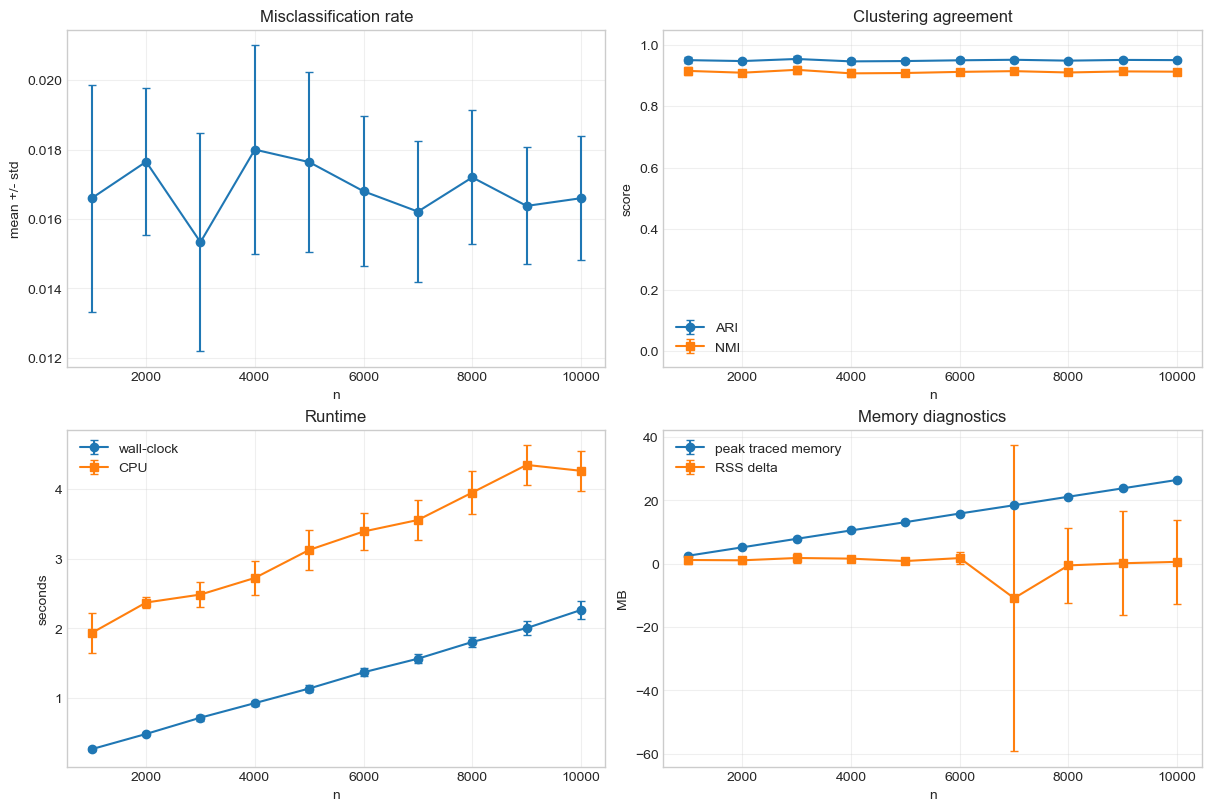

PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_summary.png')

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
x = summary["n"].to_numpy()

axes[0, 0].errorbar(
    x,
    summary["misclassification_mean"],
    yerr=summary["misclassification_std"].fillna(0.0),
    marker="o",
    capsize=3,
)
axes[0, 0].set_title("Misclassification rate")
axes[0, 0].set_xlabel("n")
axes[0, 0].set_ylabel("mean +/- std")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].errorbar(x, summary["ari_mean"], yerr=summary["ari_std"].fillna(0.0), marker="o", capsize=3, label="ARI")
axes[0, 1].errorbar(x, summary["nmi_mean"], yerr=summary["nmi_std"].fillna(0.0), marker="s", capsize=3, label="NMI")
axes[0, 1].set_title("Clustering agreement")
axes[0, 1].set_xlabel("n")
axes[0, 1].set_ylabel("score")
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].errorbar(x, summary["wall_clock_sec_mean"], yerr=summary["wall_clock_sec_std"].fillna(0.0), marker="o", capsize=3, label="wall-clock")
axes[1, 0].errorbar(x, summary["cpu_time_sec_mean"], yerr=summary["cpu_time_sec_std"].fillna(0.0), marker="s", capsize=3, label="CPU")
axes[1, 0].set_title("Runtime")
axes[1, 0].set_xlabel("n")
axes[1, 0].set_ylabel("seconds")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].errorbar(
    x,
    summary["peak_traced_memory_mb_mean"],
    yerr=summary["peak_traced_memory_mb_std"].fillna(0.0),
    marker="o",
    capsize=3,
    label="peak traced memory",
)
if summary["rss_delta_mb_mean"].notna().any():
    axes[1, 1].errorbar(
        x,
        summary["rss_delta_mb_mean"],
        yerr=summary["rss_delta_mb_std"].fillna(0.0),
        marker="s",
        capsize=3,
        label="RSS delta",
    )
axes[1, 1].set_title("Memory diagnostics")
axes[1, 1].set_xlabel("n")
axes[1, 1].set_ylabel("MB")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

fig_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

fig_path

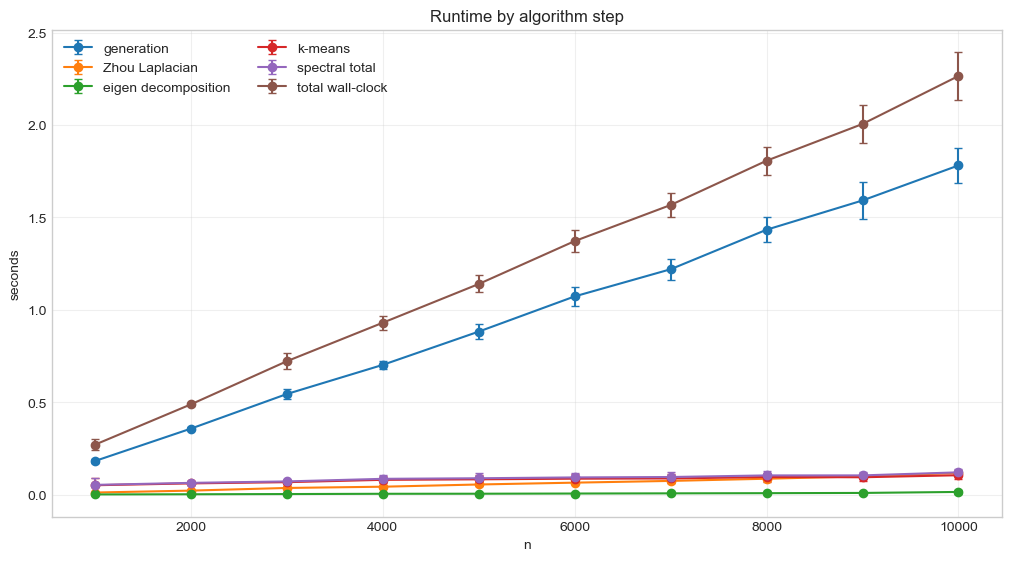

PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_runtime_breakdown.png')

In [16]:
x = summary["n"].to_numpy()

runtime_series = [
    ("generation_wall_sec", "generation"),
    ("zhou_laplacian_wall_sec", "Zhou Laplacian"),
    ("eigen_decomposition_wall_sec", "eigen decomposition"),
    ("kmeans_wall_sec", "k-means"),
    ("spectral_clustering_wall_sec", "spectral total"),
    ("wall_clock_sec", "total wall-clock"),
]

fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
for col, label in runtime_series:
    mean_col = f"{col}_mean"
    std_col = f"{col}_std"
    if mean_col not in summary.columns:
        continue
    ax.errorbar(
        x,
        summary[mean_col],
        yerr=summary[std_col].fillna(0.0) if std_col in summary.columns else None,
        marker="o",
        capsize=3,
        label=label,
    )

ax.set_title("Runtime by algorithm step")
ax.set_xlabel("n")
ax.set_ylabel("seconds")
ax.grid(alpha=0.3)
ax.legend(ncols=2)

runtime_breakdown_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_runtime_breakdown.png"
fig.savefig(runtime_breakdown_path, dpi=180, bbox_inches="tight")
plt.show()

runtime_breakdown_path

## Optional: add a larger n

Uncomment and run this cell to extend the sweep. The summary cell above will need the new frame name added to its `frames` list unless you append it manually.


In [17]:
# df_n12000 = run_n_experiment(12000)